<a href="https://colab.research.google.com/github/ammar01-me/ArtExtract_project/blob/main/ArtExtract_similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Art Extract
**For the similarity task, I used the Kaggle Best Artworks of All Time dataset instead of the National Gallery of Art dataset due to hardware limitations and availability issues.As the Kaggle dataset contains a good variety of paintings from different artists and styles, which is enough for learning visual similarity. It allowed me to efficiently train and test the model within limited resources while still getting meaningful results.The same code can be implemented for National Gallery of Art dataset with minor changes**

Author: Sayed Ammar

In [1]:
"""As the dataset provided by HumanAI resource is of 25gb and the size limit for google collab is of 10 12gb, so i used the similar dataset form kaggle to implement traning"""

from google.colab import drive
import os
drive.mount('/content/drive')

# Unziping dataset from Drive to Colab local disk
ZIP_PATH = '/content/drive/MyDrive/Project_data/archive.zip'
!unzip -q {ZIP_PATH} -d /content/data

print("Done!")
print(os.listdir('/content/data'))


Mounted at /content/drive
Done!
['artists.csv', 'resized', 'images']


### importing the module

In [2]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [24]:
torch.manual_seed(42)

### loading the model

In [3]:
model = models.resnet50(pretrained=True)

# Remove last layer
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [4]:
# transforming images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(   # NEW (important)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### loading images

In [17]:
image_folder = "/content/data/images/images"

image_paths = []
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith((".jpg", ".png", ".jpeg")):
            image_paths.append(os.path.join(root, file))

### feature Extraction

In [18]:
def extract_features(paths, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()
    features = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        images = []

        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                img = transform(img)
                images.append(img)
            except Exception as e:
                print(f"Skipping {path}: {e}")

        print(f"Batch {i}: loaded {len(images)} images")  # debug

        if len(images) == 0:
            continue

        images = torch.stack(images).to(device)

        with torch.no_grad():
            output = model(images)

        output = output.view(output.size(0), -1)
        output = output.cpu().numpy()

        features.extend(output)

    features = np.array(features)

    if len(features) == 0:
        print("No features extracted! Check image paths.")
        return None
    if len(features.shape) == 1:
        features = features.reshape(1, -1)
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    features = features / (norms + 1e-10)

    return features

In [19]:
features = extract_features(image_paths)

if features is not None:
    print("Feature shape:", features.shape)

Batch 0: loaded 16 images
Batch 16: loaded 16 images
Batch 32: loaded 16 images
Batch 48: loaded 16 images
Batch 64: loaded 16 images
Batch 80: loaded 16 images
Batch 96: loaded 16 images
Batch 112: loaded 16 images
Batch 128: loaded 16 images
Batch 144: loaded 16 images
Batch 160: loaded 16 images
Batch 176: loaded 16 images
Batch 192: loaded 16 images
Batch 208: loaded 16 images
Batch 224: loaded 16 images
Batch 240: loaded 16 images
Batch 256: loaded 16 images
Batch 272: loaded 16 images
Batch 288: loaded 16 images
Batch 304: loaded 16 images
Batch 320: loaded 16 images
Batch 336: loaded 16 images
Batch 352: loaded 16 images
Batch 368: loaded 16 images
Batch 384: loaded 16 images
Batch 400: loaded 16 images
Batch 416: loaded 16 images
Batch 432: loaded 16 images
Batch 448: loaded 16 images
Batch 464: loaded 16 images
Batch 480: loaded 16 images
Batch 496: loaded 16 images
Batch 512: loaded 16 images
Batch 528: loaded 16 images
Batch 544: loaded 16 images
Batch 560: loaded 16 images


### similarity function

In [20]:
#using cosine similarity function for finding the similar images
def find_similar(index, top_k=5):
    query = features[index].reshape(1, -1)
    similarities = cosine_similarity(query, features)[0]

    indices = similarities.argsort()[-top_k-1:-1][::-1]

    return indices, similarities[indices]

### similar image visualisation

In [26]:
def show_similar(index):
    similar_indices, scores = find_similar(index)

    plt.figure(figsize=(12, 5))

    # Query Image
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(image_paths[index]))
    plt.title("Query: ")
    plt.axis("off")

    # Similar Images
    for i, (idx, score) in enumerate(zip(similar_indices, scores)):
        plt.subplot(1, 6, i+2)
        plt.imshow(Image.open(image_paths[idx]))
        # shows similarity
        plt.title(f"similarity {score:.2f}")
        plt.axis("off")

    plt.show()

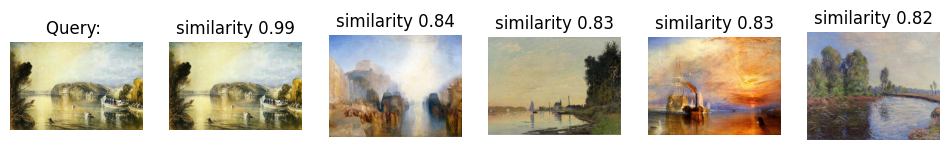

In [27]:
number_of_image = 10
show_similar(number_of_image)